In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from warnings import simplefilter
import math

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold,RepeatedStratifiedKFold
import lightgbm as lgbm


from sklearn.metrics import log_loss,accuracy_score
from sklearn.preprocessing import StandardScaler,QuantileTransformer,MinMaxScaler
from catboost import CatBoostClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

simplefilter('ignore')

%matplotlib inline


rc = {
    "axes.facecolor": "#FFF9ED",
    "figure.facecolor": "#FFF9ED",
    "axes.edgecolor": "#000000",
    "grid.color": "#EBEBE7",
    "font.family": "serif",
    "axes.labelcolor": "#000000",
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "grid.alpha": 0.4
}

sns.set(rc=rc)

from colorama import Style, Fore
red = Style.BRIGHT + Fore.RED
blu = Style.BRIGHT + Fore.BLUE
mgt = Style.BRIGHT + Fore.MAGENTA
gld = Style.BRIGHT + Fore.YELLOW
res = Style.RESET_ALL



/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
train_data = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/train.csv")
test_data = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/test.csv")
meta_data = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/greeks.csv")
sample_submit = pd.read_csv("/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv")

## Data Preview and EDA

In [3]:
sample_submit.head()

,Id,class_0,class_1
0,00eed32682bb,0.5,0.5
1,010ebe33f668,0.5,0.5
2,02fa521e1838,0.5,0.5
3,040e15f562a2,0.5,0.5
4,046e85c7cc7f,0.5,0.5


In [4]:
train_data.EJ.head()


0    B
1    A
2    B
3    B
4    B
Name: EJ, dtype: object

In [5]:
test_data.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FI,FL,FR,FS,GB,GE,GF,GH,GI,GL
0,00eed32682bb,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,010ebe33f668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,02fa521e1838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,040e15f562a2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,046e85c7cc7f,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> ### Observations

In [6]:
def explore_data(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['data type'])
    summ['#missing'] = df.isnull().sum().values
    summ['%missing'] = df.isnull().sum().values / len(df)
    summ['#unique'] = df.nunique().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['min'] = desc['min'].values
    summ['max'] = desc['max'].values
    summ['count']= desc['count'].values
    summ['mean']= desc['mean'].values
    summ['std']= desc['std'].values
    summ['25%']= desc['25%'].values
    summ['50%']= desc['50%'].values
    summ['75%']= desc['75%'].values

    
    return summ

display(explore_data(train_data))

data shape: (617, 58)


,data type,#missing,%missing,#unique,min,max,count,mean,std,25%,50%,75%
Id,object,0,0.000000,617,NaN,NaN,617,NaN,NaN,NaN,NaN,NaN
AB,float64,0,0.000000,217,0.081187,6.161666,617.0,0.477149,0.468388,0.252107,0.354659,0.559763
AF,float64,0,0.000000,599,192.59328,28688.18766,617.0,3502.013221,2300.322717,2197.34548,3120.31896,4361.63739
AH,float64,0,0.000000,227,85.200147,1910.123198,617.0,118.624513,127.83895,85.200147,85.200147,113.73954
AM,float64,0,0.000000,605,3.177522,630.51823,617.0,38.968552,69.728226,12.270314,20.53311,39.139886
AR,float64,0,0.000000,130,8.138688,178.943634,617.0,10.128242,10.518877,8.138688,8.138688,8.138688
AX,float64,0,0.000000,427,0.699861,38.27088,617.0,5.545576,2.551696,4.128294,5.031912,6.431634
AY,float64,0,0.000000,148,0.025578,10.315851,617.0,0.06032,0.416817,0.025578,0.025578,0.036845
AZ,float64,0,0.000000,484,3.396778,38.971568,617.0,10.566447,4.350645,8.12958,10.46132,12.969516
BC,float64,0,0.000000,259,1.2299,1463.693448,617.0,8.053012,65.166943,1.2299,1.2299,5.081244


In [7]:
display(explore_data(test_data))

data shape: (5, 57)


,data type,#missing,%missing,#unique,min,max,count,mean,std,25%,50%,75%
Id,object,0,0.0,5,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN
AB,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AF,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AH,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AM,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AR,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AX,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AY,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
AZ,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0
BC,float64,0,0.0,1,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_data.head()

,Id,AB,AF,AH,AM,AR,AX,AY,AZ,BC,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,000ff2bfdfe9,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,007255e47698,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,013f2bd269f5,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,043ac50845d5,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,044fb8a146ec,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [9]:
train_data['Class'].value_counts(normalize=True).map("{:.2%}".format).to_frame().T

,0,1
Class,82.50%,17.50%


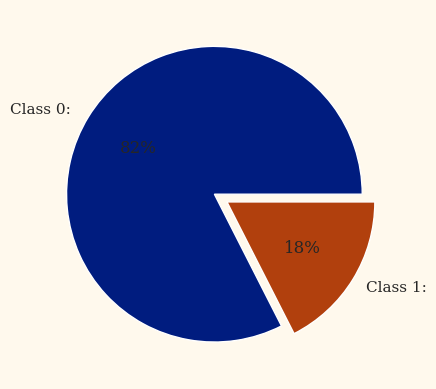

In [10]:
keys = ['Class 0: ', 'Class 1:']
class_df = train_data['Class'].value_counts(normalize=True)
explode = [0, 0.1]
palette_color = sns.color_palette('dark')
  
plt.pie(class_df, labels=keys, colors=palette_color,
        explode=explode, autopct='%.0f%%')
plt.show()   
    

In [11]:
target = "Class"
numerical= [col for col in train_data.select_dtypes(["int64", "float64","int32", "float32"]).columns if col not in [target,"Id"]]
categorical = [col for col in train_data.select_dtypes("object").columns if col not in [target,"Id"]]
print("Numerical Columns:\n",numerical)
print("\n")
print("Categorical Columns:\n",categorical)

Numerical Columns:
 ['AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN', 'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS', 'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY', 'EB', 'EE', 'EG', 'EH', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI', 'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL']


Categorical Columns:
 ['EJ']


In [12]:
train_data['EJ'].value_counts(normalize=True).map("{:.2%}".format).to_frame().T

,B,A
EJ,64.02%,35.98%


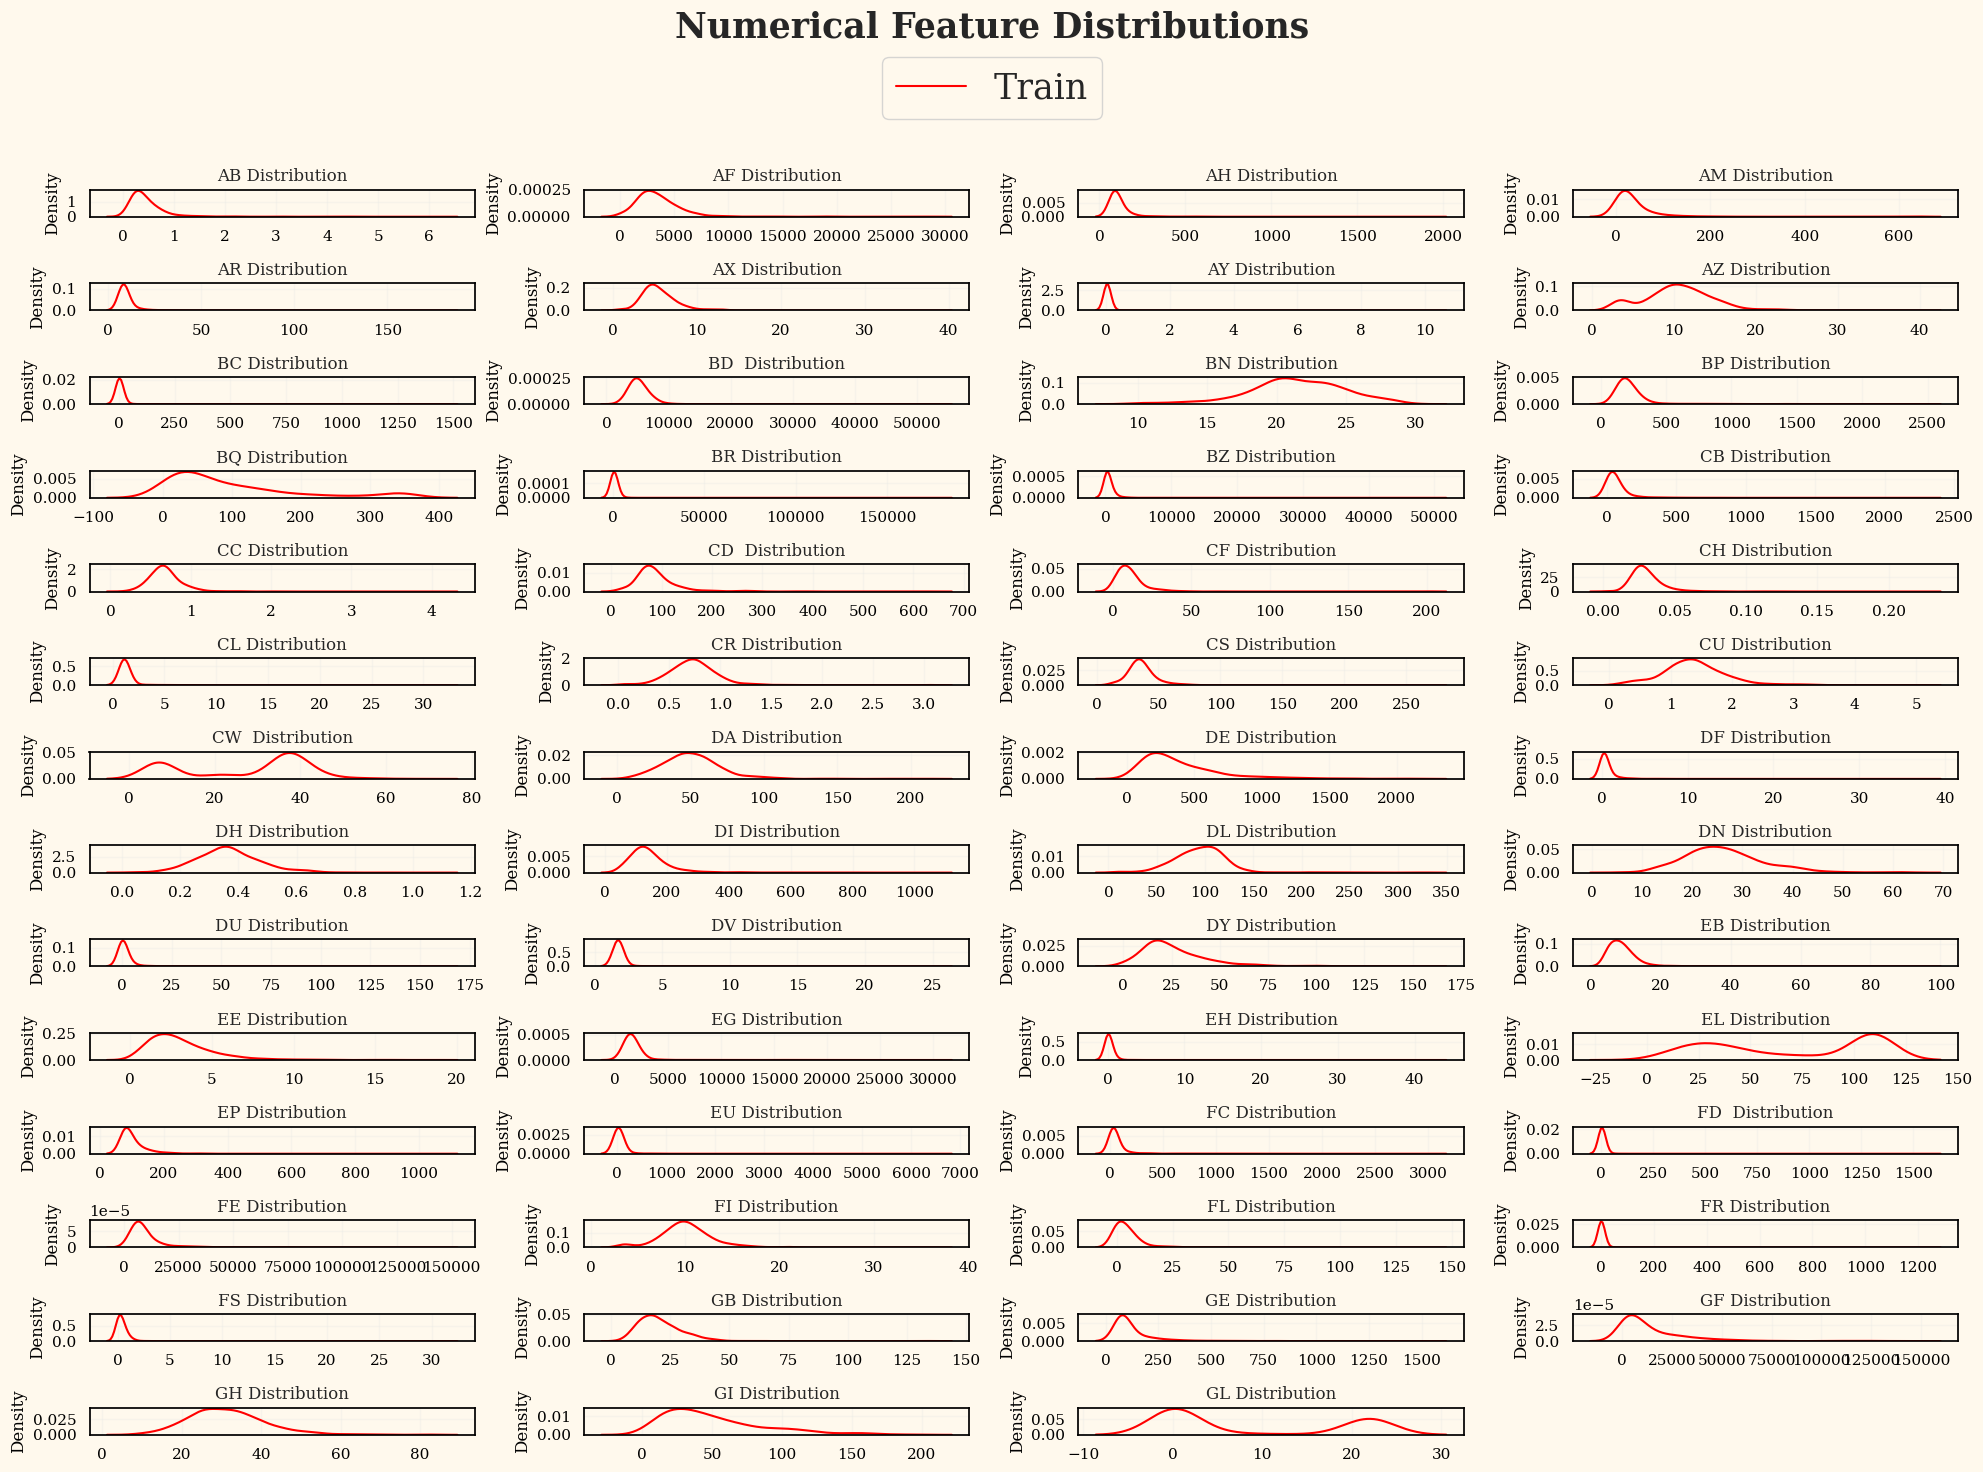

In [13]:
features = numerical
columns = features
n_cols = 4
n_rows = math.ceil(len(columns)/n_cols)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 15))
ax = ax.flatten()

for i, column in enumerate(columns):
    plot_axes = [ax[i]]
    sns.kdeplot(
        train_data[column], label='Train',
        ax=ax[i], color='red'
    )
    

  # titles
    ax[i].set_title(f'{column} Distribution');
    ax[i].set_xlabel(None)
    
    # remove axes to show only one at the end
    plot_axes = [ax[i]]
    handles = []
    labels = []
    for plot_ax in plot_axes:
        handles += plot_ax.get_legend_handles_labels()[0]
        labels += plot_ax.get_legend_handles_labels()[1]
        plot_ax.legend().remove()
    
for i in range(i+1, len(ax)):
    ax[i].axis('off')
    
fig.suptitle(f'Numerical Feature Distributions\n\n\n', ha='center',  fontweight='bold', fontsize=25)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize=25, ncol=3)
plt.tight_layout()

In [14]:
def distr_shape(df):
    print(f'data shape: {df.shape}')
    data_explore = pd.DataFrame(df.dtypes, columns=['data type'])
    data_explore['skewness'] = df.skew(numeric_only=True)
    data_explore['kurtosis'] = df.kurtosis()
    
    return data_explore

display(distr_shape(train_data))

data shape: (617, 58)


,data type,skewness,kurtosis
Id,object,NaN,NaN
AB,float64,5.927245,53.027994
AF,float64,3.751057,30.046579
AH,float64,10.094184,123.880298
AM,float64,6.434969,48.583199
AR,float64,13.259275,202.672415
AX,float64,4.400920,45.729751
AY,float64,24.270320,597.760144
AZ,float64,0.799989,3.506581
BC,float64,19.726787,420.083106


In [15]:
train_data.drop('Id', axis = 1, inplace = True)

In [16]:
train_data.head()

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class
0,0.209377,3109.03329,85.200147,22.394407,8.138688,0.699861,0.025578,9.812214,5.555634,4126.58731,...,7.298162,1.73855,0.094822,11.339138,72.611063,2003.810319,22.136229,69.834944,0.120343,1
1,0.145282,978.76416,85.200147,36.968889,8.138688,3.632190,0.025578,13.517790,1.229900,5496.92824,...,0.173229,0.49706,0.568932,9.292698,72.611063,27981.562750,29.135430,32.131996,21.978000,0
2,0.470030,2635.10654,85.200147,32.360553,8.138688,6.732840,0.025578,12.824570,1.229900,5135.78024,...,7.709560,0.97556,1.198821,37.077772,88.609437,13676.957810,28.022851,35.192676,0.196941,0
3,0.252107,3819.65177,120.201618,77.112203,8.138688,3.685344,0.025578,11.053708,1.229900,4169.67738,...,6.122162,0.49706,0.284466,18.529584,82.416803,2094.262452,39.948656,90.493248,0.155829,0
4,0.380297,3733.04844,85.200147,14.103738,8.138688,3.942255,0.054810,3.396778,102.151980,5728.73412,...,8.153058,48.50134,0.121914,16.408728,146.109943,8524.370502,45.381316,36.262628,0.096614,1


In [17]:
#check duplicate rows
duplicate = train_data[train_data.duplicated()]
 
#print("Duplicate Rows :")
# Print the resultant Dataframe
duplicate

,AB,AF,AH,AM,AR,AX,AY,AZ,BC,BD,...,FL,FR,FS,GB,GE,GF,GH,GI,GL,Class


In [18]:
train_data.drop_duplicates(inplace=True)

> ## Outliers

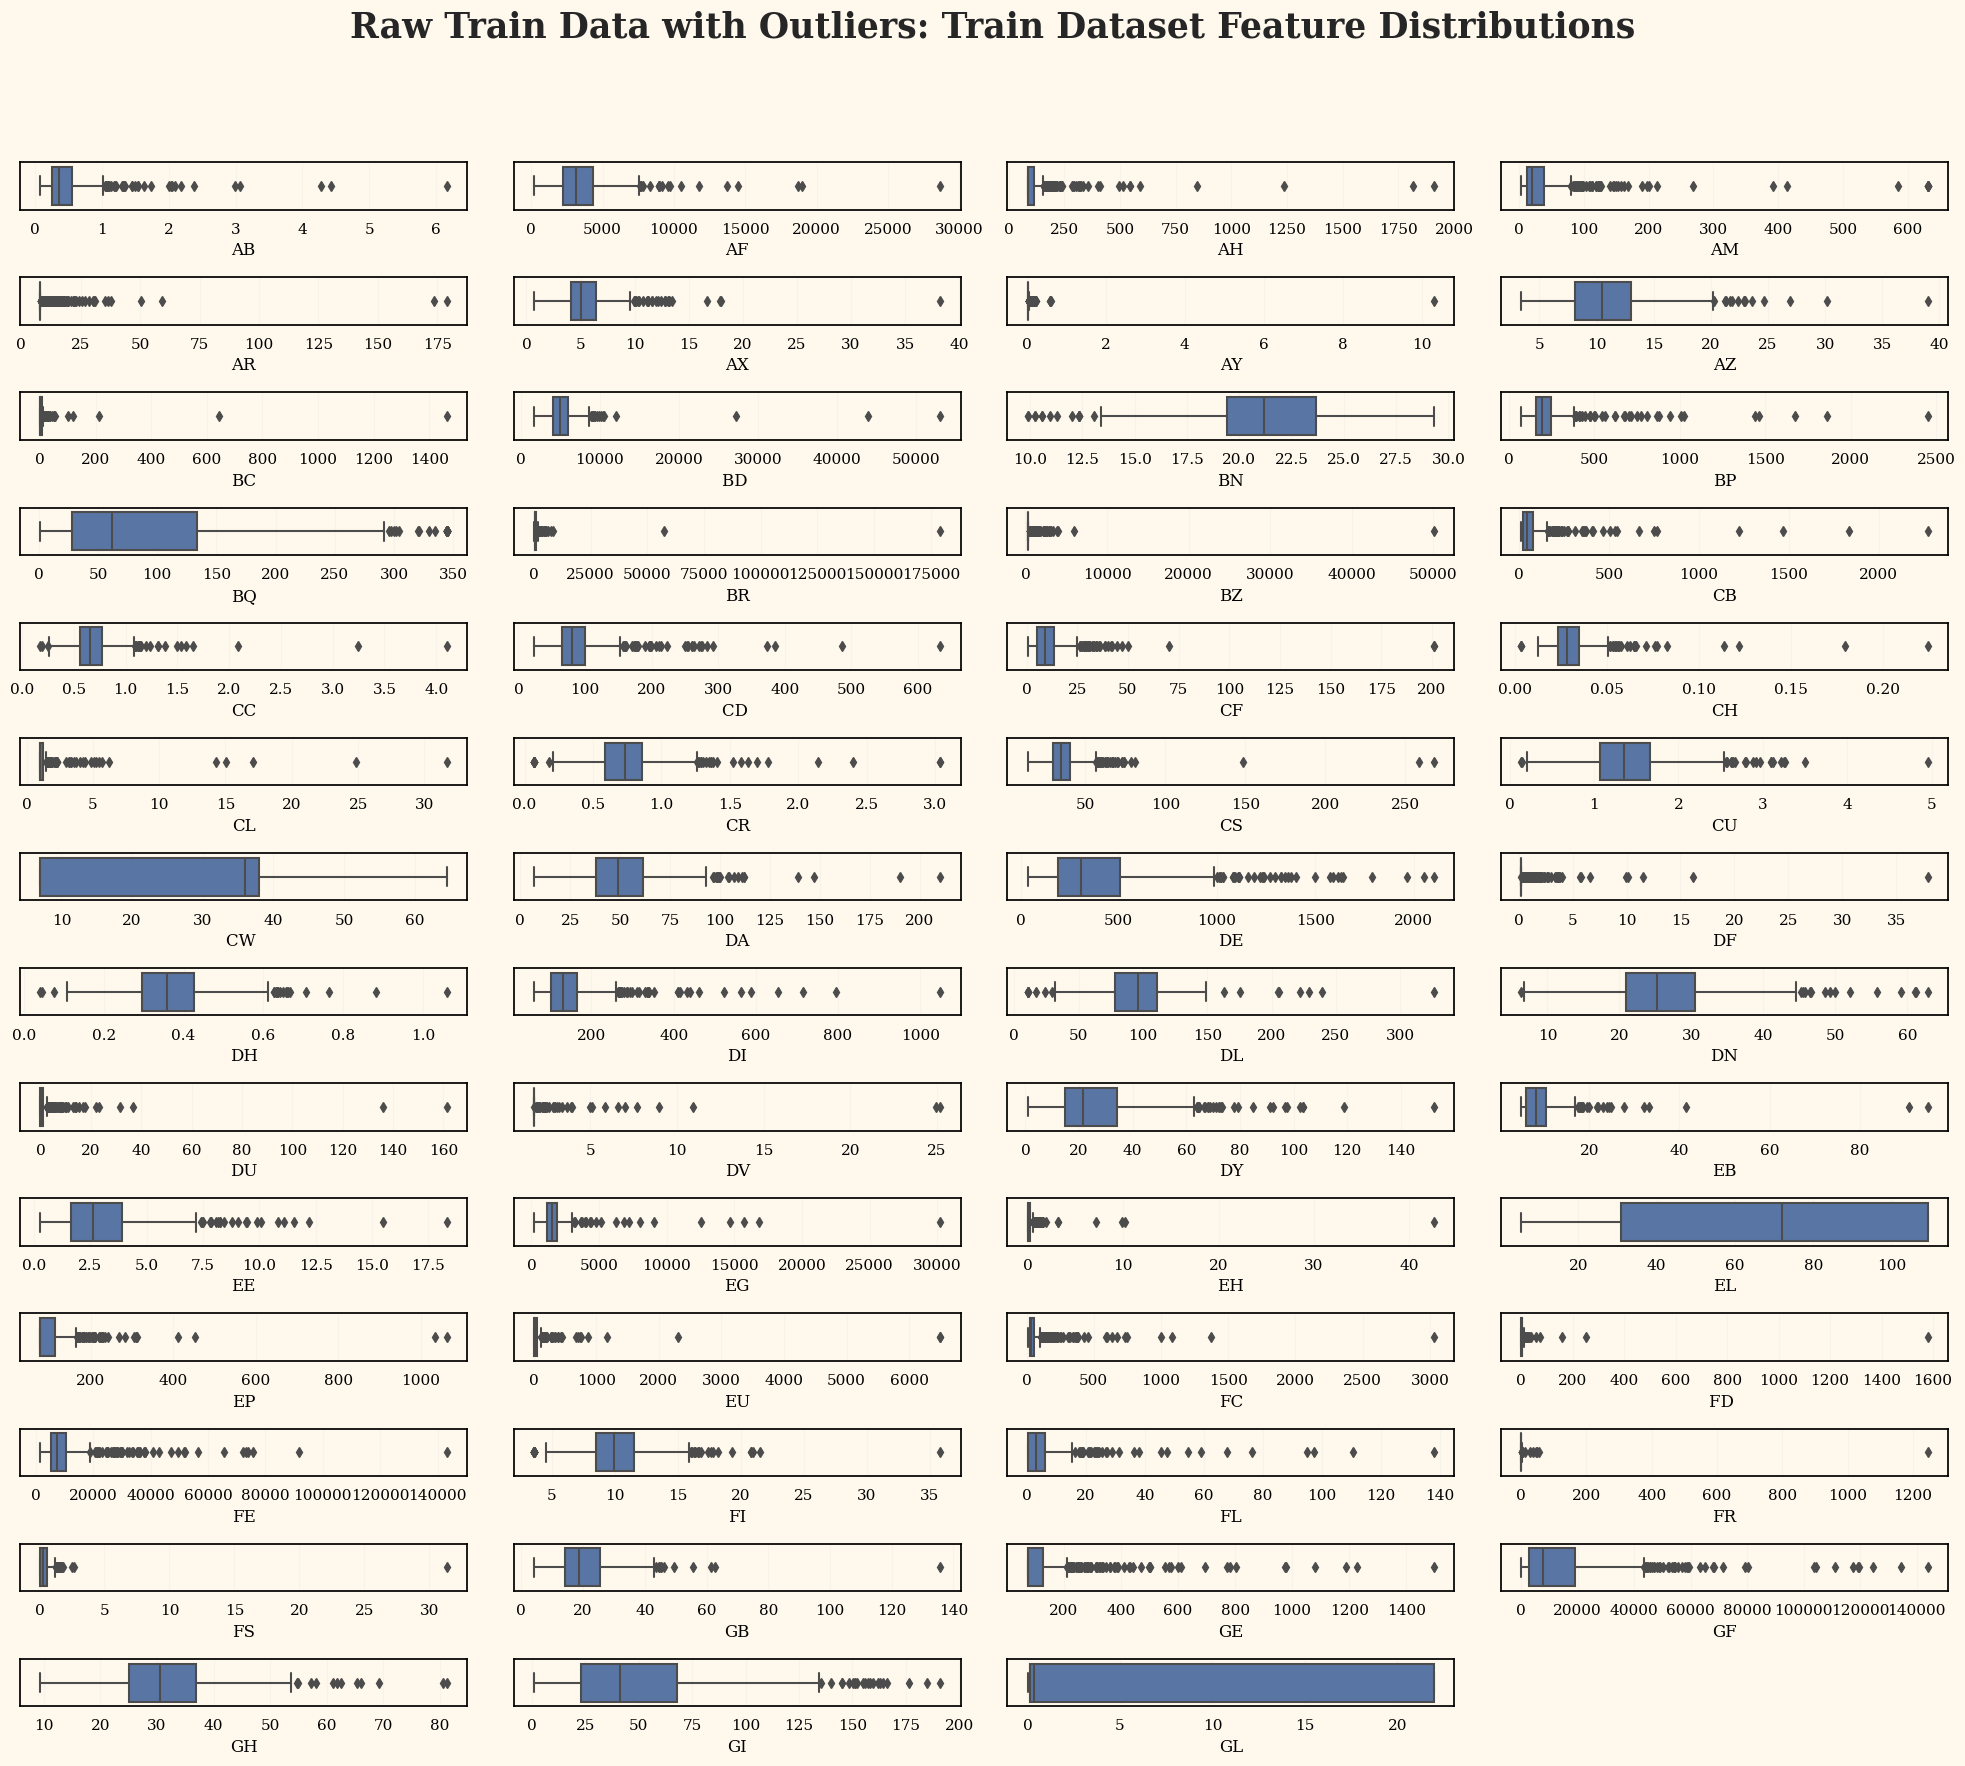

In [19]:
rows, cols = math.ceil(len(numerical) / 4), 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 18))

for col, ax in zip(numerical, axes.flatten()):
    sns.boxplot(data=train_data,
                 x=col,
                 ax=ax)
   
    ax.set_ylabel('')
    
    
    
for ax in axes.flatten():
    if not ax.get_xlabel():
        ax.set_visible(False)

fig.suptitle(f'Raw Train Data with Outliers: Train Dataset Feature Distributions\n\n\n', ha='center',  fontweight='bold', fontsize=25)

plt.tight_layout()


In [20]:
# If we decide to treat the outliers. we can use this function:
def handle_outliers(df,fea):
    for col in fea:
    #Step-5: Finding the IQR
        percentile25 = df[col].quantile(0.25)
        percentile75 = df[col].quantile(0.75)
        iqr = percentile75 - percentile25
    
    #Step-6: Finding the upper and lower limits

        upper_limit = percentile75 + 1.5 * iqr
        lower_limit = percentile25 - 1.5 * iqr

    #Step-7: Finding outliers

        df[df[col] > upper_limit]
        df[df[col] < lower_limit]
    #Step-8: Either Trimming outliers
        #df = df[(df[col] < upper_limit) & (df[col]>lower_limit)]
    # OR Capping
  
        df[col] = np.where(df[col] > upper_limit,upper_limit,
                           np.where(df[col] < lower_limit,lower_limit,df[col]))
    return df

train_data = handle_outliers(train_data,numerical)
test_data = handle_outliers(test_data,numerical)

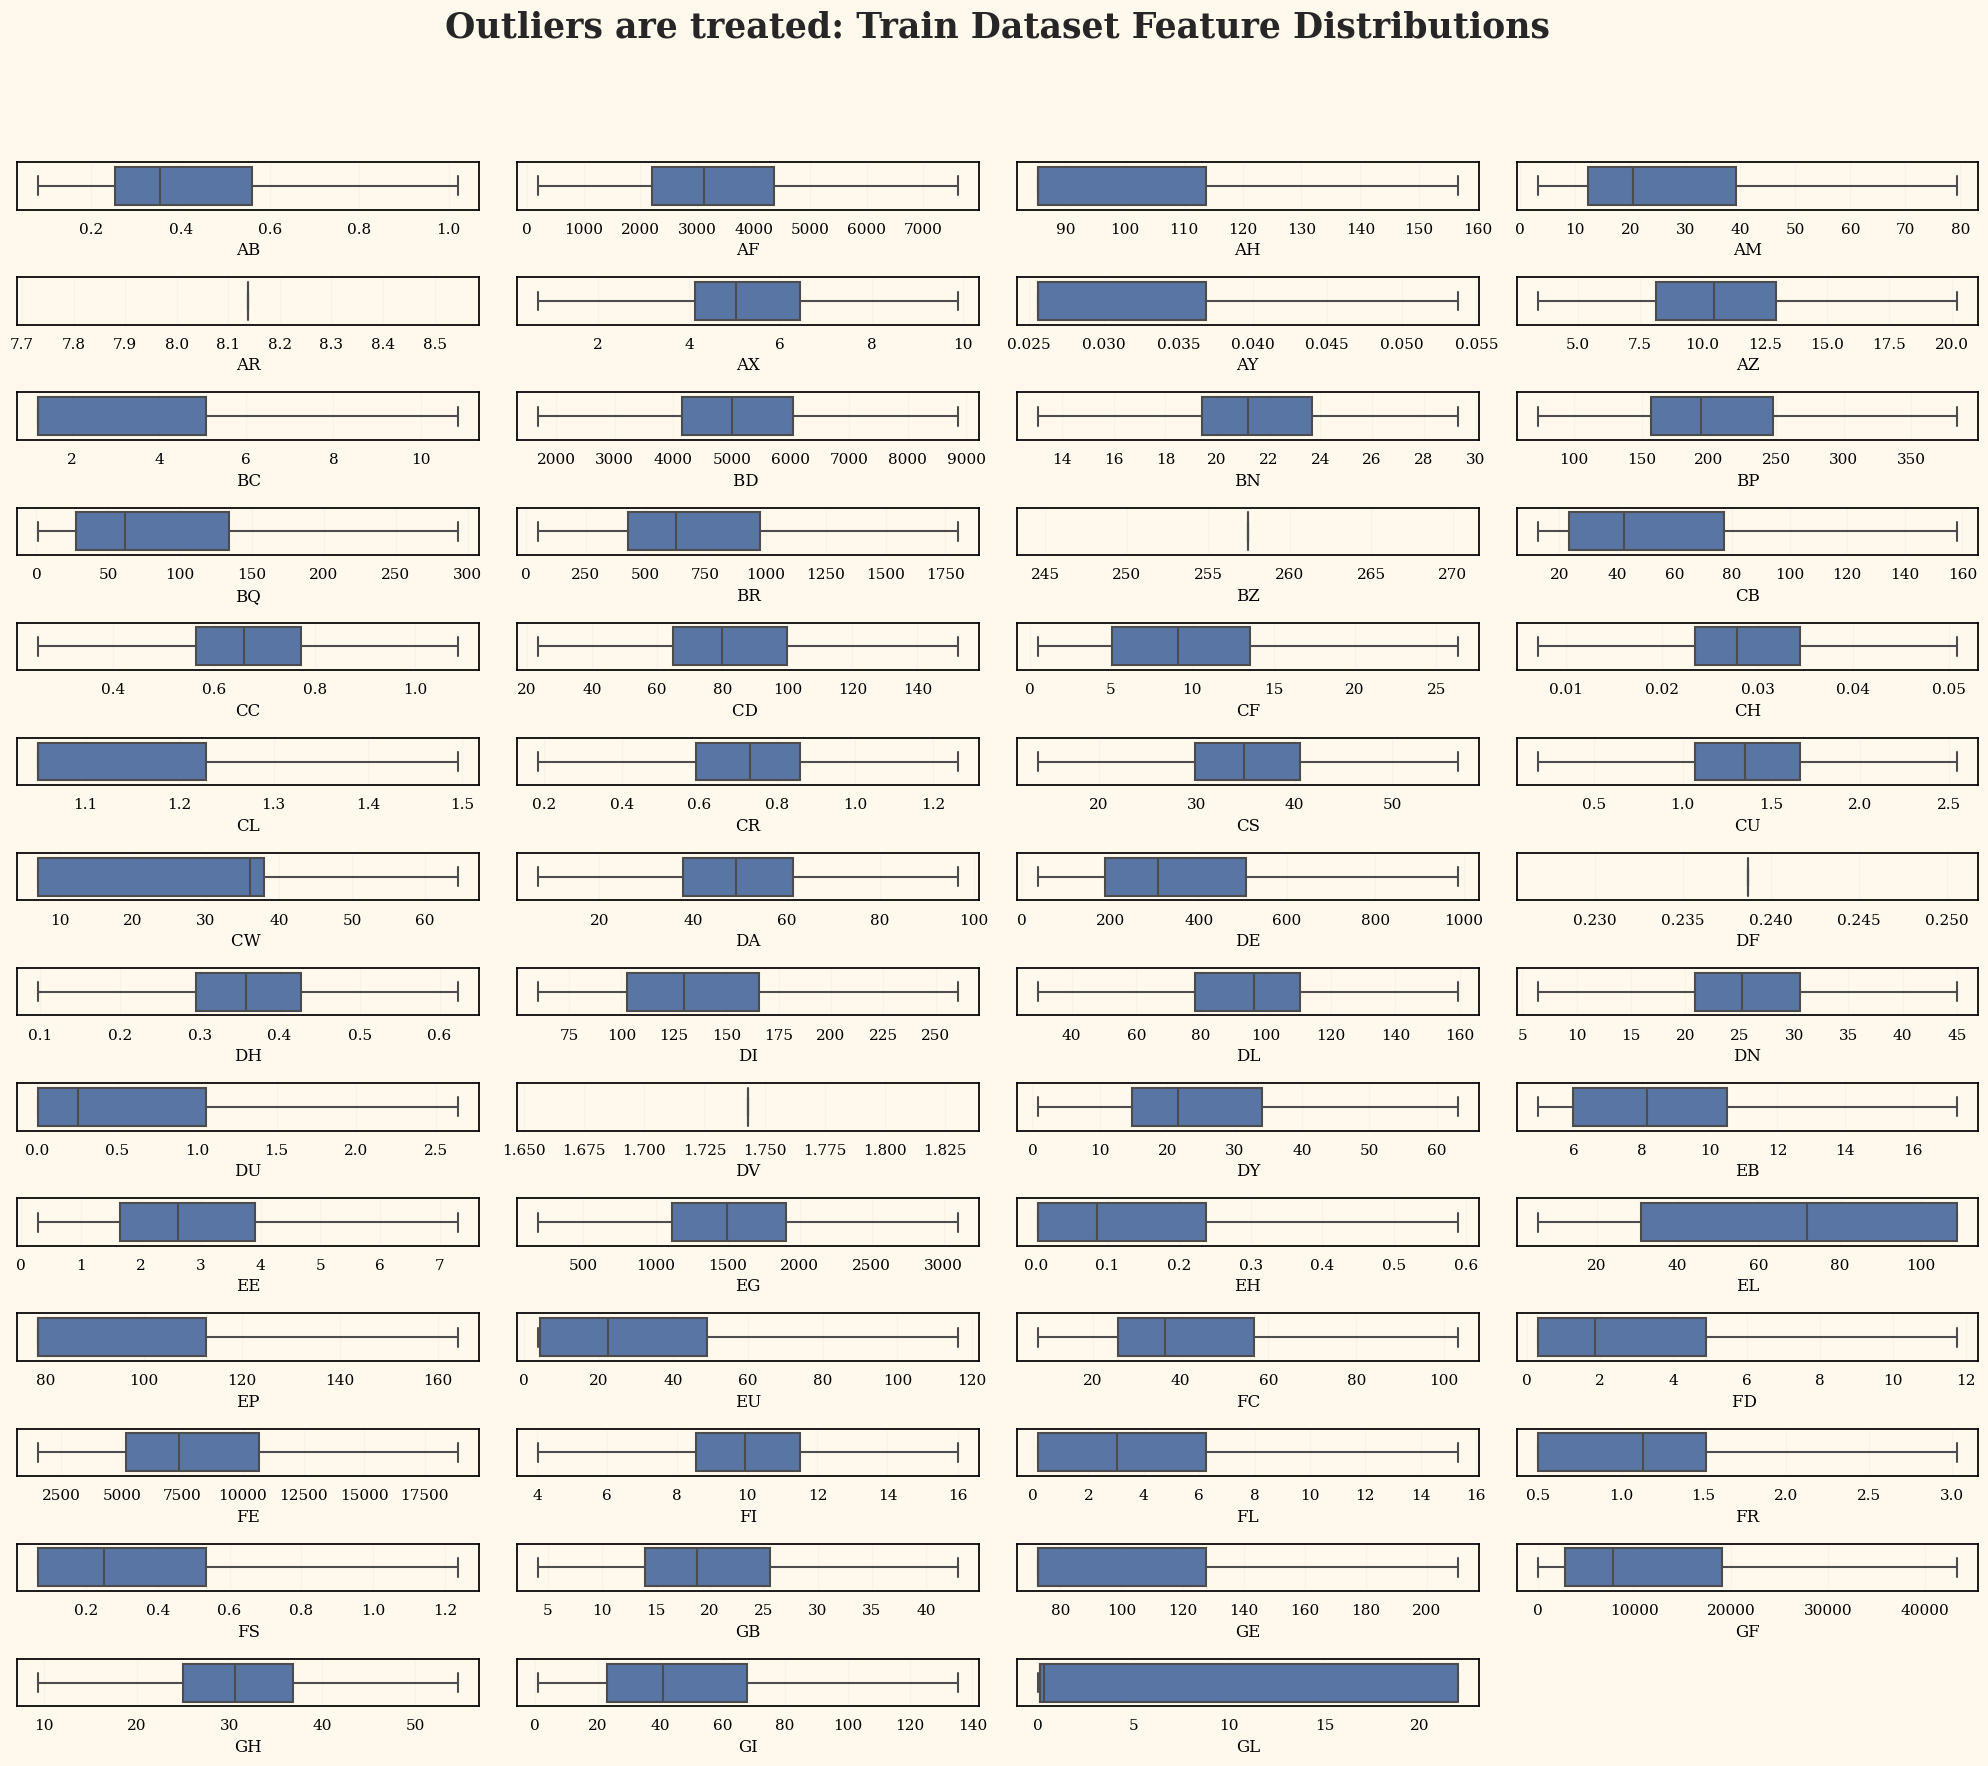

In [21]:
rows, cols = math.ceil(len(numerical) / 4), 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 18))

for col, ax in zip(numerical, axes.flatten()):
    sns.boxplot(data=train_data,
                 x=col,
                 ax=ax)
   
    ax.set_ylabel('')
    
    
    
for ax in axes.flatten():
    if not ax.get_xlabel():
        ax.set_visible(False)

fig.suptitle(f'Outliers are treated: Train Dataset Feature Distributions\n\n\n', ha='center',  fontweight='bold', fontsize=25)

plt.tight_layout()


In [22]:
def model_cv_score(model,features,label):    
    
    va_scores = []
    tr_scores = []

    oof_preds_0 = []
    oof_preds_1 = []
    oof_models = []

    
    sk=StratifiedKFold(n_splits=10, random_state=42,shuffle=True)
    X = train_data[features]
    y  = train_data[target]
    # enumerate splits
    for fold, (train_ix, test_ix) in enumerate(sk.split(X,y)):
        X_train, X_test = X.iloc[train_ix], X.iloc[test_ix]
        y_train, y_test = y.iloc[train_ix], y.iloc[test_ix]
        
        model.fit(X_train, y_train)
            
        
        va_pred = model.predict_proba(X_test)[:,1]
        tr_pred = model.predict_proba(X_train)[:,1]
    
        va_scores.append(log_loss(y_test,va_pred))
        tr_scores.append(log_loss(y_train,tr_pred))
    
        # output for prediction using data from test.csv
        
        oof_preds_1.append(model.predict_proba(test_data[features])[:,1])
        
        oof_models.append(model)
        
        
        
        #overfit= 100*np.abs((np.mean(tr_scores)-np.mean(va_scores))/np.mean(va_scores))
    
    print('Model',label,'10-fold Valid LogLoss score:',np.mean(va_scores))
    #print("Train LogLoss score:",np.mean(tr_scores))

    return np.mean(va_scores),np.std(va_scores),oof_preds_1,oof_models

In [23]:
# impute and encode

features = numerical + categorical

numerical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy ='median')),('scaler',StandardScaler())])
categorical_transformer = Pipeline(steps=[('imputer',SimpleImputer(strategy ='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('num',numerical_transformer,numerical),('cat',categorical_transformer,categorical)])

### RandomForestClassifier

In [24]:

 
estimator = RandomForestClassifier(n_estimators=148, 
                                   criterion='log_loss',
                                   max_depth=14, 
                                   random_state = 42)
    


model = Pipeline(steps=[('preprocessor',preprocessor),('estimator', estimator)])



rf_score,rf_std,rf_oof_preds_1,rf_oof_models = model_cv_score(model,features,label='rf')
rf_pred_1 = np.mean(rf_oof_preds_1,axis = 0)


#output predictions data
output = pd.DataFrame({'Id': test_data.Id, 'class_0': 1-rf_pred_1, 'class_1': rf_pred_1})
output.to_csv('submission_Random.csv', index=False)



Model rf 10-fold Valid LogLoss score: 0.23116964429861264


In [25]:
!head submission_Random.csv

Id,class_0,class_1
00eed32682bb,0.6067567567567568,0.3932432432432432
010ebe33f668,0.6067567567567568,0.3932432432432432
02fa521e1838,0.6067567567567568,0.3932432432432432
040e15f562a2,0.6067567567567568,0.3932432432432432
046e85c7cc7f,0.6067567567567568,0.3932432432432432


### LogisticRegression

In [26]:
estimator = LogisticRegression(max_iter = 4,random_state=2)
model = Pipeline(steps=[('preprocessor',preprocessor),('estimator', estimator)])
Logi_score,Logi_std,logi_oof_preds_1,logi_oof_models = model_cv_score(model,features,label='LOGISTIC')

Model LOGISTIC 10-fold Valid LogLoss score: 0.2252147109772687


In [27]:
logi_pred_1 = np.mean(logi_oof_preds_1,axis = 0)

#output predictions data
output = pd.DataFrame({'Id': test_data.Id, 'class_0': 1-logi_pred_1, 'class_1': logi_pred_1})
output.to_csv('submission_logi.csv', index=False)

In [28]:
!head submission_logi.csv

Id,class_0,class_1
00eed32682bb,0.871201308837738,0.12879869116226197
010ebe33f668,0.871201308837738,0.12879869116226197
02fa521e1838,0.871201308837738,0.12879869116226197
040e15f562a2,0.871201308837738,0.12879869116226197
046e85c7cc7f,0.871201308837738,0.12879869116226195


### CatBoostClassifier

In [29]:
estimator = CatBoostClassifier(#task_type = "GPU",
                                        n_estimators=142, 
                                        loss_function='Logloss', 
                                       eval_metric='Logloss',
                                       learning_rate = 0.1,
                                       max_depth=4,
                                       l2_leaf_reg = 3,
                                       random_state=42,verbose=0) 
model = Pipeline(steps=[('preprocessor',preprocessor),('estimator', estimator)])
Cat_score,Cat_std,Cat_oof_preds_1,Cat_oof_models = model_cv_score(model,features,label='CatBoost')

Model CatBoost 10-fold Valid LogLoss score: 0.17779298033700172


In [30]:
Cat_pred_1 = np.mean(Cat_oof_preds_1,axis = 0)

#output predictions data
output = pd.DataFrame({'Id': test_data.Id, 'class_0': 1-Cat_pred_1, 'class_1': Cat_pred_1})
output.to_csv('submission_Cat.csv', index=False)

In [31]:
!head submission_Cat.csv

Id,class_0,class_1
00eed32682bb,0.7357487447137407,0.2642512552862592
010ebe33f668,0.7357487447137407,0.2642512552862592
02fa521e1838,0.7357487447137407,0.2642512552862592
040e15f562a2,0.7357487447137407,0.2642512552862592
046e85c7cc7f,0.7357487447137407,0.2642512552862592


In [32]:
aver_pred = (Cat_pred_1 + rf_pred_1 + logi_pred_1)/3.0

#output predictions 
output = pd.DataFrame({'Id': test_data.Id, 'class_0': 1- aver_pred, 'class_1': aver_pred})
output.to_csv('submission.csv', index=False)

In [33]:
!head submission.csv

Id,class_0,class_1
00eed32682bb,0.7379022701027452,0.26209772989725477
010ebe33f668,0.7379022701027452,0.26209772989725477
02fa521e1838,0.7379022701027452,0.26209772989725477
040e15f562a2,0.7379022701027452,0.26209772989725477
046e85c7cc7f,0.7379022701027452,0.26209772989725477
